In [20]:
#import the dataset
from sklearn.datasets import load_breast_cancer
import pandas as pd

# Load dataset
data = load_breast_cancer()

# Features
X = pd.DataFrame(data.data, columns=data.feature_names)

# Target
y = pd.Series(data.target)

# Quick check
print(X.head())
print(y.value_counts())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  worst texture  worst perimeter  \
0           

In [21]:
print(X.columns)

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension'],
      dtype='str')


In [22]:
print(X.shape, y.shape)

(569, 30) (569,)


0
       mean radius  mean texture  mean perimeter    mean area  \
count   569.000000    569.000000      569.000000   569.000000   
mean     14.127292     19.289649       91.969033   654.889104   
std       3.524049      4.301036       24.298981   351.914129   
min       6.981000      9.710000       43.790000   143.500000   
25%      11.700000     16.170000       75.170000   420.300000   
50%      13.370000     18.840000       86.240000   551.100000   
75%      15.780000     21.800000      104.100000   782.700000   
max      28.110000     39.280000      188.500000  2501.000000   

       mean smoothness  mean compactness  mean concavity  mean concave points  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813        0.079720             0.038803   
min           0.052630          0.019380        0.000000             0.000000   
25%    

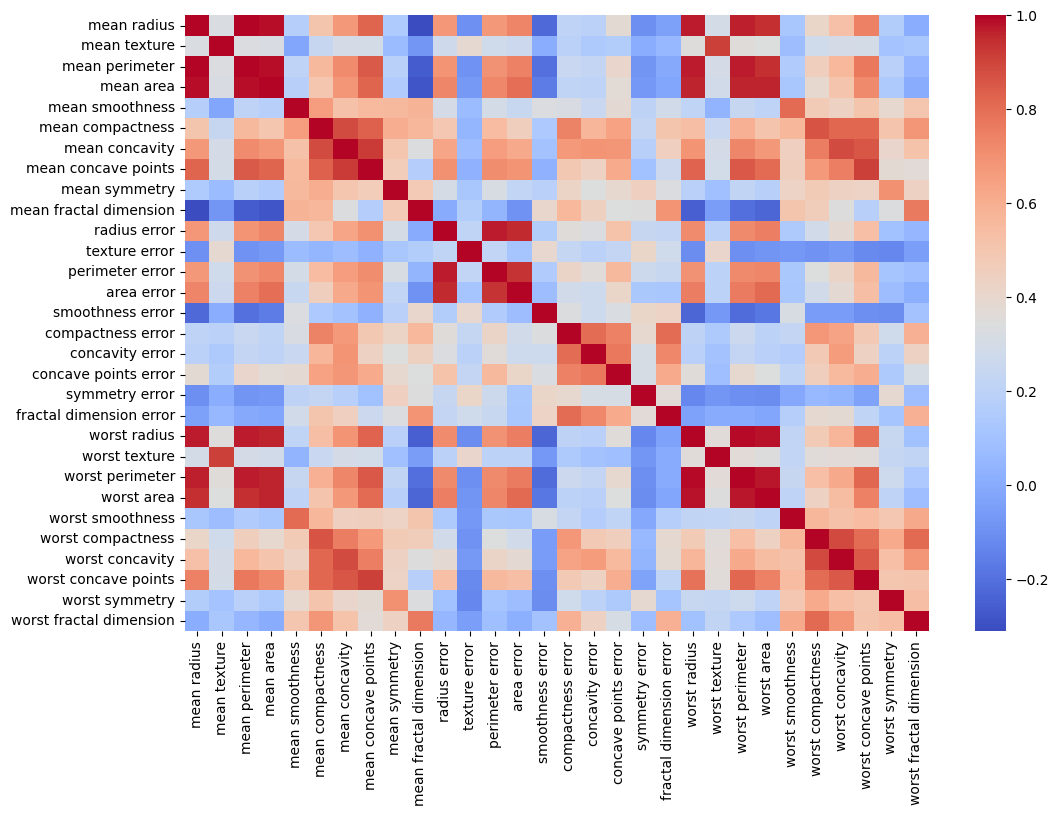

In [23]:
# Check missing values
print(X.isnull().sum().sum())  # Should be 0

# Describe stats
print(X.describe())

# Correlation heatmap 
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))
sns.heatmap(X.corr(), cmap="coolwarm")
plt.show()

In [24]:
from sklearn.model_selection import train_test_split

# Split 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
#stratify=y to keep same class distribution

In [25]:
#baseline logistic regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Train model
model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9649122807017544
Confusion Matrix:
 [[39  3]
 [ 1 71]]
Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.93      0.95        42
           1       0.96      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



In [26]:
#observations:
# - Logistic regression acheived an accuracy of 96%
# - benign has higher recall and malignant has lower recall
# - benign has lower precision
# - In medical datasets recall of malignant cases(class 0) is most important


In [27]:
#scaling & model comparison
from sklearn.preprocessing import StandardScaler
#Scaling for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression with Scaling
model_scaled = LogisticRegression(max_iter=5000)
model_scaled.fit(X_train_scaled, y_train)
y_pred_scaled = model_scaled.predict(X_test_scaled)
print("Scaled Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_scaled))

Scaled Logistic Regression Accuracy: 0.9824561403508771


In [28]:
from sklearn.ensemble import RandomForestClassifier
# Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.956140350877193


In [29]:
from sklearn.tree import DecisionTreeClassifier
# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.9122807017543859


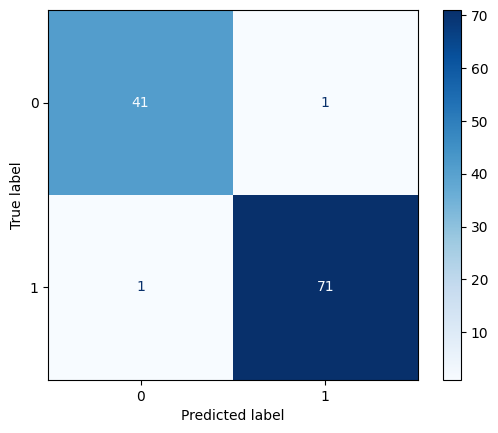

In [30]:
#confusion matrix for scaled logistic regression
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_scaled, cmap='Blues')
plt.show()

In [31]:
#observations
# 1 Logistic regression(without scaling)
# - The baseline Logistic Regression model achieved an accuracy of 96%.
# - Performance is decent but slightly affected by differences in feature scales.
# - Since Logistic Regression is distance-based, it is sensitive to feature magnitude differences.

# 2 Logistic regression(with scaling)
# - After applying StandardScaler, accuracy improved to 98%.
# - Scaling helped the model converge better and improved overall stability.
# - Recall for the malignant class (0) improved, which is very important in medical classification problems.
# -This confirms that scaling is crucial for linear models.

# 3 Random Forest Classifier
# - Accuracy: 96%
# - It reduces overfitting compared to a single Decision Tree.
# - Provides strong baseline performance without heavy preprocessing.

# 4 Decision tree classifier
# - Accuracy: 91%
# - Decision Trees do not require scaling.
# - Model performs well but may slightly overfit depending on depth.
# - Trees can capture nonlinear relationships better than Logistic Regression.

In [32]:
# | Model               | Scaling Applied | Notes                              |
# | ------------------- | --------------- | ---------------------------------- |
# | Logistic Regression | ❌ No            | Baseline linear model              |
# | Logistic Regression | ✅ Yes           | Improved convergence & performance |
# | Decision Tree       | ❌ No            | Captures nonlinear patterns        |
# | Random Forest       | ❌ No            | Best overall performance           |


In [35]:
#Why ROC/AUC Is Important For YOU
# In medical problems:
# - We care about separating positive and negative patients well
# - Threshold may change depending on risk tolerance
# - ROC shows full picture

#If Logistic Regression has:
# - High Recall
# - High AUC
# - Then it is strong and reliable.

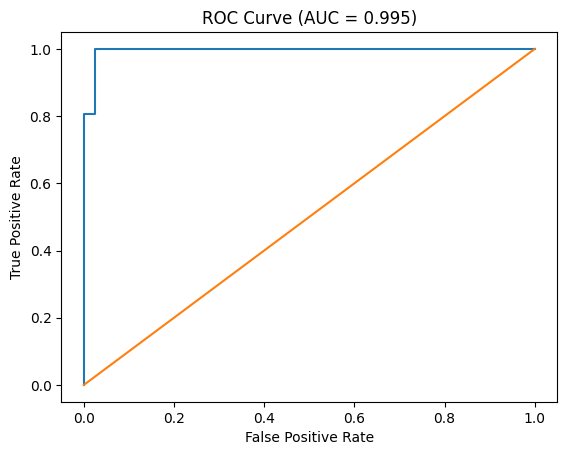

AUC: 0.9953703703703703


In [36]:
#ROC and AUC
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# probabilities
y_prob = model_scaled.predict_proba(X_test_scaled)[:, 1]

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# AUC score
auc_score = roc_auc_score(y_test, y_prob)

# plot
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1])  # random line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (AUC = {auc_score:.3f})")
plt.show()

print("AUC:", auc_score)


In [37]:
# AUC = 0.99
# Recall (malignant) is high
# The model is medically reliable.
#why AUC is higher?
# - The dataset has well-separated classes
# - Features like mean radius, texture, perimeter are strong predictors
# - Logistic Regression works well when separation is mostly linear

In [38]:
#Tune Logistic regression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['liblinear']
}

grid = GridSearchCV(
    LogisticRegression(max_iter=5000),
    param_grid,
    cv=5,
    scoring='recall'  # because medical dataset
)

grid.fit(X_train_scaled, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Recall:", grid.best_score_)

C:\Users\Admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\Admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\Admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was depr

Best Parameters: {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}
Best CV Recall: 0.9894736842105264


C:\Users\Admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\Admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\Admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was depr

In [39]:
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test_scaled)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [40]:
# why regularization?
# To prevent overfitting by penalizing large coefficients and improving generalization performance.